### 0️⃣ Imports & Style

In [17]:
from visualizations import plot_loss_history
# %load_ext is safe to repeatedly run in a Jupyter notebook; it will just ignore duplicates.
#%reload_ext autoreload
#%autoreload 2
%matplotlib inline

In [18]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["font.family"] = "DejaVu Sans"   # works on all OSes
import seaborn as sns

# Figures
#sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "lines.linewidth": 2,
})

# Repo imports (assumes repo root is on PYTHONPATH)
from model import InverseSchrodingerModel
from utils import make_grid, set_global_seed
from physics import tise_loss, potential_smoothness_loss, wavefunction_normalization_loss
from inverse import data_mismatch_loss
from pod import pod_decomposition
from visualizations import *

set_global_seed(27)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Part 1 - Training the Model

### 1️⃣ Synthetic problem definition
Create a 1-D harmonic oscillator test case for the inverse Schrödinger model to try and recover.

In [19]:
# Spatial grid
n_points = 256        # Number of collocation points
x = make_grid(-5.0, 5.0, n_points)       # (n_points, 1) -> n_points collocation points
dx = float(x[1] - x[0])                  # grid spacing (scalar)

# Choose a known analytic potential (e.g., harmonic oscillator)
V_true = 0.5 * x.squeeze()**2       # shape (N,)

# Analytic eigenfunctions (Hermite-Gaussians) for the chosen analytic potential (harmonic oscillator)
def hermite_gauss(n: int, x_vals: torch.Tensor) -> torch.Tensor:
    """Return the nth normalized harmonic oscillator eigenfunction."""
    from math import factorial, sqrt, pi
    import scipy.special as sp
    norm = 1.0 / sqrt(2.0**n * factorial(n)) * (pi**-0.25)
    # sp.hermite returns a callable polynomial; evaluate on x_vals
    return norm * sp.hermite(n)(x_vals) * torch.exp(-0.5 * x_vals**2)

n_states = 3     # number of eigenstates to evaluate/learn
psi_true = [hermite_gauss(n, x.squeeze()) for n in range(n_states)]
E_true = torch.tensor([0.5, 1.5, 2.5])  # exact energies (hbar = omega = 1)

# Synthetic observed data with some noise so the model has something to fit
rho_obs = [psi**2 + 0.02 * torch.randn_like(psi) for psi in psi_true]
E_obs = E_true + 0.05 * torch.randn_like(E_true)

### 2️⃣ Training loop
Train the inverse Schrödinger model on synthetic observed data (defined above).

In [20]:
# ============================================================================
# 🎛️ CONFIGURATION PARAMETERS
# ============================================================================
# Training hyperparameters
lr              = 5e-3      # Learning rate
epochs          = 6_000     # Number of training epochs
log_every       = 800       # Print loss every N epochs

# Loss weights (static throughout training)
lamda_data      = 1.0
lambda_physics  = 4.0
lambda_smooth   = 5e-4
lambda_norm     = 1.0

# Build the network
model = InverseSchrodingerModel(
    n_states=n_states,
    hidden_dims=[64, 64],
    device=device,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

lambdas = {
    "data": lamda_data,
    "physics": lambda_physics,
    "smooth": lambda_smooth,
    "norm": lambda_norm,
}

# ----------------------------------------------------------------------
# Training loop (with component logging)
# ----------------------------------------------------------------------

loss_history = []
physics_history = []    # TISE  residual
data_history = []       # data-fit
smooth_history = []     # potential smoothness
norm_history = []       # normalized wavefunction penalty

for epoch in range(1, epochs + 1):
    # Run a single optimization step and retrieve the three components
    optimizer.zero_grad()

    # ------------------- Physics‑informed loss -------------------
    loss_physics = tise_loss(
        model.psi_theta(x),     # list[psi_n(theta, x)]
        model.V_theta(x),       # V(theta, x)
        model.E_theta(),        # E(theta)
        dx,
    )

    # ------------------- Physics‑informed loss -------------------
    loss_physics = tise_loss(
        model.psi_theta(x),     # list[psi_n(theta, x)]
        model.V_theta(x),       # V(theta, x)
        model.E_theta(),        # E(theta)
        dx,
    )

    # ------------------- Smoothness regularizer -------------------
    loss_smooth = potential_smoothness_loss(model.V_theta(x), dx)

    # ------------------- Data‑fit loss ----------------------------
    loss_data = data_mismatch_loss(
        model.psi_theta(x),     # learned psi_n(theta, x)
        model.E_theta(),        # learned energies
        rho_obs,                # observed probability densities
        E_obs,                  # observed energies
    )

    # ------------------- Normalization penalty -------------------
    loss_norm = wavefunction_normalization_loss(
        model.psi_theta(x),
        dx
    )

    # ------------------- Weighted sum ----------------------------
    total_loss = (
        lambdas["data"] * loss_data
        + lambdas["physics"] * loss_physics
        + lambdas["smooth"] * loss_smooth
        + lambdas["norm"] * loss_norm
    )

    total_loss.backward()
    optimizer.step()

    # ------------------- Store scalars ---------------------------
    loss_history.append(total_loss.item())
    physics_history.append(loss_physics.item())
    data_history.append(loss_data.item())
    smooth_history.append(loss_smooth.item())
    norm_history.append(loss_norm.item())

    # ----- logging -----------------------------------------------
    if epoch % log_every == 0 or epoch == 1:
        print(f" epoch {epoch:4d} | total={total_loss.item():.6e} "
              f" | phys={loss_physics.item():.6e} "
              f" | data={loss_data.item():.6e} "
              f" | smooth={loss_smooth.item():.6e}"
              f" | norm={loss_norm.item():.6e}")

# ----------------------------------------------------------------------
# Post-training sanity check
# ----------------------------------------------------------------------
initial_loss = loss_history[0]
final_loss = loss_history[-1]
print("\n ✔️ Training complete!")
print(f"Initial loss: {initial_loss:.6e}")
print(f"Final loss: {final_loss:.6e}")

 epoch    1 | total=7.950353e+00  | phys=5.803761e-02  | data=7.380219e+00  | smooth=3.279174e-01 | norm=3.378191e-01
 epoch  800 | total=3.688484e-01  | phys=4.676070e-03  | data=3.494592e-01  | smooth=8.378991e-01 | norm=2.659669e-04
 epoch 1600 | total=3.022287e-02  | phys=2.189573e-03  | data=1.926496e-02  | smooth=3.832209e+00 | norm=2.835055e-04
 epoch 2400 | total=9.063247e-03  | phys=5.777758e-04  | data=3.915867e-03  | smooth=5.366584e+00 | norm=1.529845e-04
 epoch 3200 | total=5.844232e-03  | phys=5.136591e-04  | data=1.488881e-03  | smooth=4.119020e+00 | norm=2.412046e-04
 epoch 4000 | total=5.186255e-03  | phys=4.856056e-04  | data=1.329852e-03  | smooth=3.800496e+00 | norm=1.373185e-05
 epoch 4800 | total=5.073381e-03  | phys=4.846820e-04  | data=1.295502e-03  | smooth=3.676062e+00 | norm=1.119139e-06
 epoch 5600 | total=5.031084e-03  | phys=4.885402e-04  | data=1.280962e-03  | smooth=3.589646e+00 | norm=1.138441e-06

 ✔️ Training complete!
Initial loss: 7.950353e+00
Final

#### Build a DataFrame for the loss history

In [21]:
epoch_numbers = list(range(1, len(loss_history) + 1))

df = pd.DataFrame(
    {
        "epoch": epoch_numbers,
        "total": loss_history,
        "physics": physics_history,
        "norm": norm_history,
        "smooth": smooth_history,
        "data": data_history,
    }
)

## Part 2 - Generate Figures to Analyze

### 1️⃣ Plot the loss curves

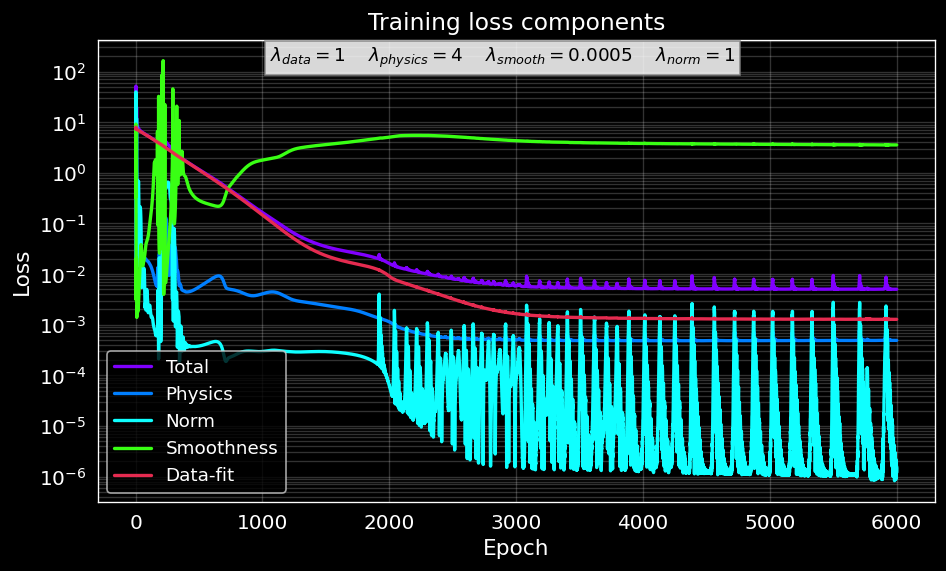

In [22]:
loss_path = pathlib.Path("../artifacts/demo_visuals/training_curves.png")
fig = plot_loss_history(
    epochs=df["epoch"],
    total=df["total"],
    physics=df["physics"],
    norm=df["norm"],
    smooth=df["smooth"],
    data=df["data"],
    lambdas=lambdas,
    out_path=loss_path,
)

## 2️⃣ Figure 2: Learned potential vs. Ground truth potential

### 📈 Plot
- $V_\theta(x)$ vs. $x$
- Ground truth $V(x)$ vs. $x$

### 🏡 Messages
- Smoothness prior effect
- Identifiability limits
- Bias vs. variance tradeoff

### ✖️ Failure modes
- Flattening
- Over-smoothing
- Boundary artifacts

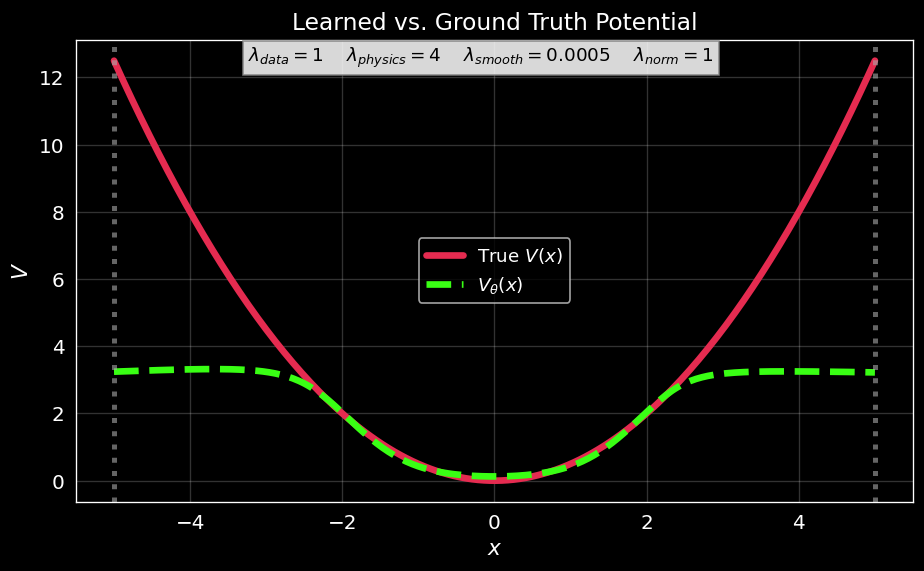

In [23]:
# Extract tensors -> ensure they are on CPU for Matplotlib
V_true_tensor = V_true.squeeze().cpu()
V_learned_tensor = model.V_theta(x).squeeze().detach().cpu()

potential_path = pathlib.Path("../artifacts/demo_visuals/learned_potential.png")
fig = plot_potential(
    x=x,
    V_true=V_true_tensor,
    V_learned=V_learned_tensor,
    lambdas=lambdas,
    out_path=potential_path,
)

### 3️⃣ Figure 3: Learned wave function $\psi_n^\theta(x)$
#### 📈 Plot
- Learned $\psi_0^\theta$, $\psi_1^\theta$ and $\psi_2^\theta$ vs. Ground Truth $\psi_0$, $\psi_1$ and $\psi_2$  (3 subplots)

#### 🏘️ Messages
- Phase ambiguity
- Shape consistency
- Node Structure

> ✨ Do _not_ claim correctness; just structure.

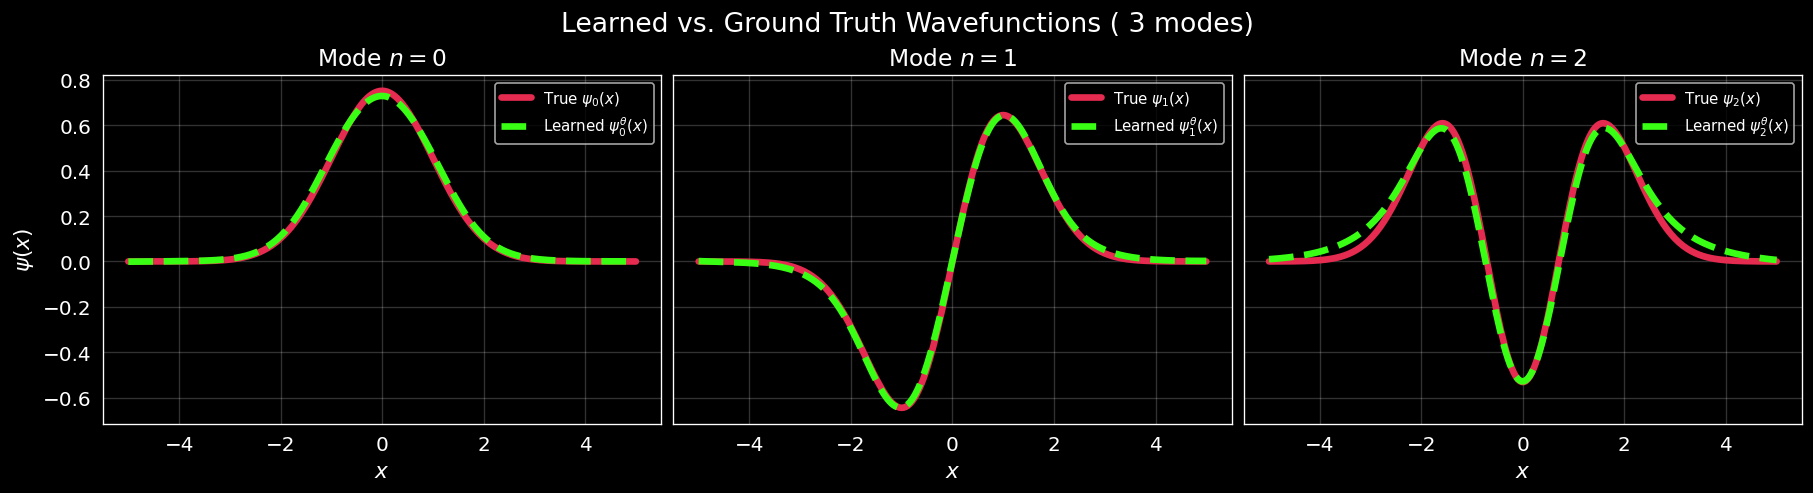

In [24]:
def _as_float(
        tensor: torch.Tensor,
        target_dtype: torch.dtype = torch.float32,
) -> torch.Tensor:
    """Return a contiguous 1-D tensor with the desired dtype."""
    return tensor.squeeze().to(dtype=target_dtype)

# Aligned signs
aligned_psi = []
for true_wf, learned_wf in zip(psi_true, model.psi_theta(x)):
    true_fp = _as_float(true_wf)        # defaults to float32
    learned_fp = _as_float(learned_wf)  # ensures learned_fp is also float32
    overlap = torch.dot(true_fp, learned_fp)
    aligned_psi.append(-learned_wf if overlap < 0 else learned_wf)

psi_learned_detached = [
    wf.detach() for wf in aligned_psi
]

psi_true_detached = [
    wf.detach() for wf in psi_true
]

wf_path = pathlib.Path("../artifacts/demo_visuals/learned_wavefunctions.png")
fig = plot_wavefunctions(
    x=x,
    psi_true=psi_true_detached,
    psi_learned=psi_learned_detached,
    out_path=wf_path,
)

### Quick Diagnostics

In [25]:
# --------------------------------------------------------------
# 1️⃣  Verify data flow & basic statistics (you already did this)
# --------------------------------------------------------------
print("x shape:", x.shape)                     # (N, 1)
print("V_true min / max:", V_true.min().item(), V_true.max().item())
print("psi_true means :", [p.mean().item() for p in psi_true])
print("psi_learned means :", [p.mean().item() for p in psi_learned_detached])

# --------------------------------------------------------------
# 2️⃣  Re‑compute the loss components for the *current* forward pass
# --------------------------------------------------------------
model.train()                     # put the model in training mode (drops dropout, etc.)

V_pred      = model.V_theta(x)                # (N, 1)
psi_pred    = model.psi_theta(x)              # list of (N, 1) tensors
E_pred      = model.E_theta()                 # (n_states,)

# ------------------------------------------------------------------
# 3️⃣  Compute each loss term (same formulas you use in train_step)
# ------------------------------------------------------------------
# Physics (TISE) loss
L_physics = tise_loss(psi_pred, V_pred, E_pred, dx)

# Smoothness regularizer on the potential
L_smooth = potential_smoothness_loss(V_pred, dx)

# Data‑fit loss (density + energy)
L_data = data_mismatch_loss(psi_pred, E_pred, rho_obs, E_obs)

# Wavefunction normalization loss
L_norm = wavefunction_normalization_loss(V_pred, dx)

# Weighted total loss – use the same λ’s you defined earlier
total_loss = (
    lambdas["data"]    * L_data
    + lambdas["physics"] * L_physics
    + lambdas["smooth"]  * L_smooth
    + lambdas["norm"] * L_norm
)

print("\n--- Loss breakdown (current forward pass) ---")
print(f"Physics loss   : {L_physics.item():.6e}")
print(f"Smoothness loss: {L_smooth.item():.6e}")
print(f"Data loss      : {L_data.item():.6e}")
print(f"Wavefunction normalization loss: {L_norm.item():.6e}")
print(f"TOTAL loss     : {total_loss.item():.6e}")

# --------------------------------------------------------------
# 4️⃣  Back‑propagate to get gradients
# --------------------------------------------------------------
model.zero_grad()                # clears any stale grads
total_loss.backward()           # now gradients are populated

# --------------------------------------------------------------
# 5️⃣  Report mean absolute gradient magnitude per parameter
# --------------------------------------------------------------
print("\n--- Gradient magnitudes (mean absolute) ---")
for name, param in model.named_parameters():
    if param.grad is not None:
        grad_mean = param.grad.abs().mean().item()
        print(f"{name:30s}  {grad_mean:.3e}")
    else:
        print(f"{name:30s}  No grad")

x shape: torch.Size([256, 1])
V_true min / max: 0.00019223030540160835 12.5
psi_true means : [0.1875437105088527, -8.673617379884035e-18, 0.13260981002277814]
psi_learned means : [0.1909949779510498, 0.0003876485279761255, 0.14726145565509796]

--- Loss breakdown (current forward pass) ---
Physics loss   : 4.906809e-04
Smoothness loss: 3.557153e+00
Data loss      : 1.277015e-03
Wavefunction normalization loss: 6.077911e-01
TOTAL loss     : 6.128094e-01

--- Gradient magnitudes (mean absolute) ---
energies                        1.412e-05
potential_net.net.0.weight      9.652e-03
potential_net.net.0.bias        4.566e-03
potential_net.net.2.weight      1.286e-03
potential_net.net.2.bias        2.509e-03
potential_net.net.4.weight      1.037e-01
potential_net.net.4.bias        2.180e-01
psi_nets.0.net.0.weight         2.811e-05
psi_nets.0.net.0.bias           5.391e-05
psi_nets.0.net.2.weight         5.123e-05
psi_nets.0.net.2.bias           1.189e-04
psi_nets.0.net.4.weight         1.17

### 4️⃣ Figure 4: Energy spectrum comparison

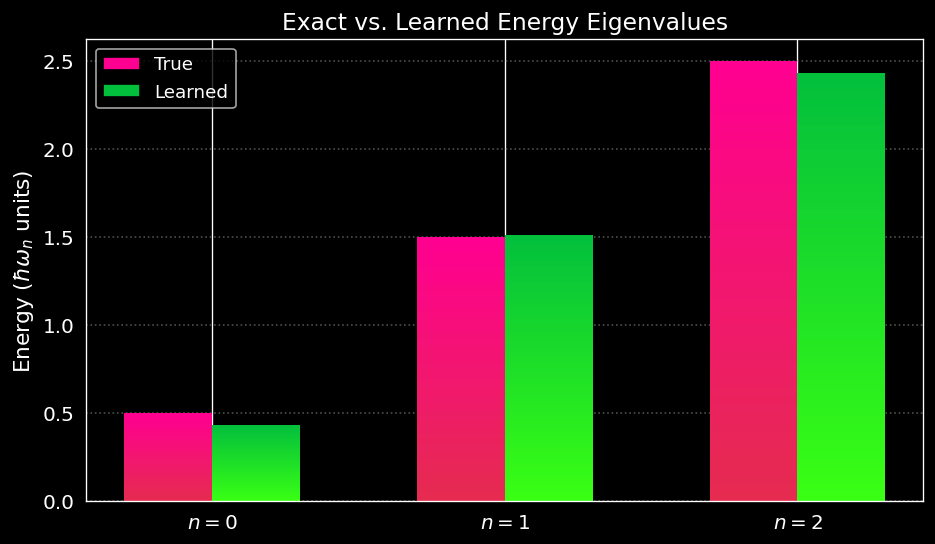

In [26]:
E_learned = model.E_theta().detach()    # shape (n_states,)

fig = plot_energy_spectrum(
    E_true=E_true,          # whatever tensor you already have
    E_learned=E_learned,
    out_path=pathlib.Path("../artifacts/demo_visuals/learned_energies.png"),
)

## 5️⃣ Figure 5: Probability densities $|\psi_n^\theta(x)|^2$ vs. observations
- Plot
    -  $|\psi_n^\theta(x)|^2$
    - Observed $\rho_n^\text{obs}(x)$
- Message
    - Data anchoring
    - Indirect supervision
    - Why phase remains unconstrained

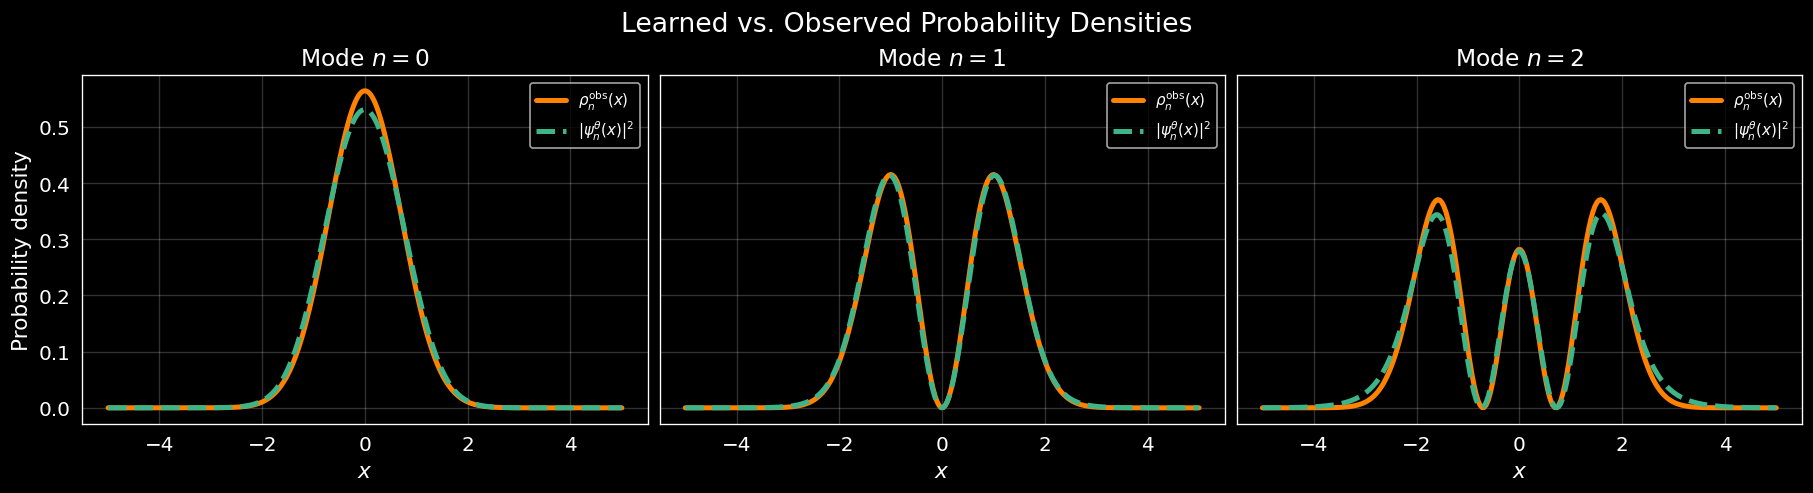

In [27]:
# --------------------------------------------------------------
# Create fake observed data for `rho_obs` (ideal case)
# --------------------------------------------------------------
rho_obs = [torch.abs(pt.squeeze())**2 for pt in psi_true]    # ideal case

fig = plot_density_vs_observed(
    x=x,
    psi_learned=psi_pred,
    rho_obs=rho_obs,
    lambdas=None,
    out_path=pathlib.Path("../artifacts/demo_visuals/density.png"),
)

## 6️⃣ Figure 6: Overlap matrix heatmap (POD diagnostic)
- Plot
    - Heatmap of $\langle \psi_m | \psi_n \rangle$
- Message
    - Near-orthogonality emerges (or not)
    - Coupling through shared $V(x)$
- ✨ This is very important for interpretability.

In [28]:
# figure 6 code

## 7️⃣ Figure 7: POD singular values
- Plot
    - Singular values $\sigma_k$ vs. $k$ (log scale)
- Message
    - Effective dimensionality
    - Redundant modes
    - Capacity vs. constraint
- Failure mode
    - One dominant singular value -> collapse (❓)

In [29]:
# figure 7 code

## 8️⃣ Figure 8: POD singular values and dominant modes

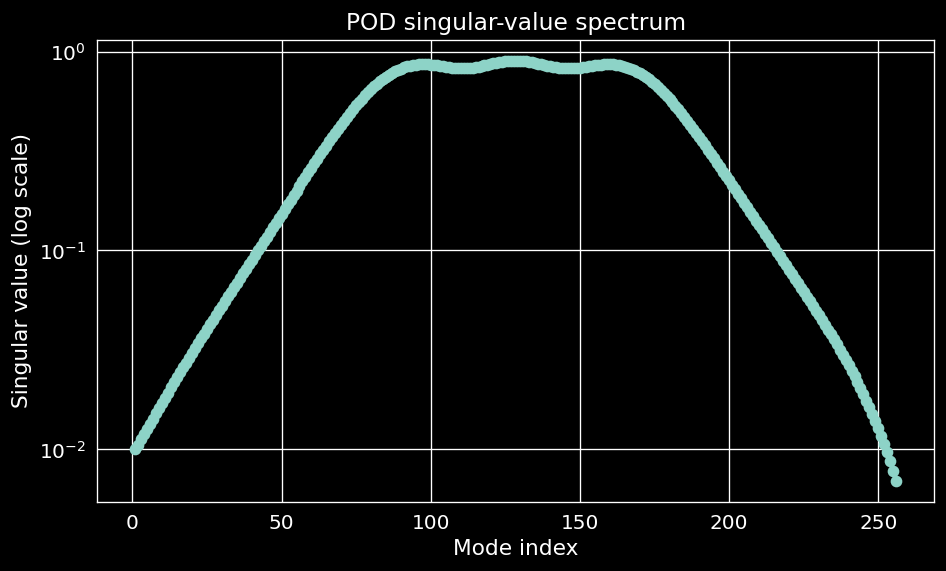

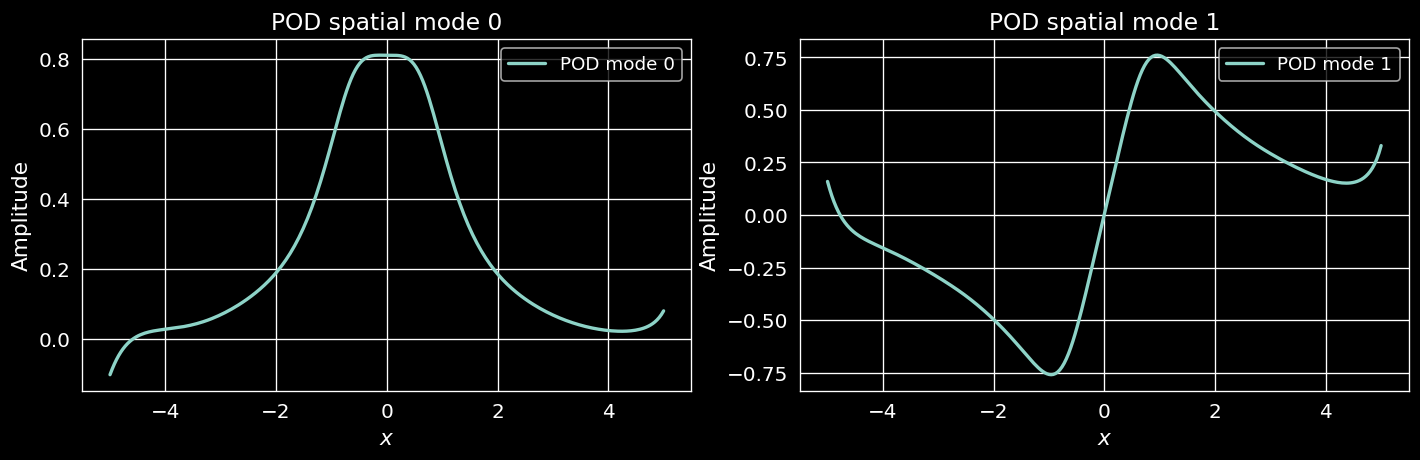

In [30]:
# Stack the learned wavefunctions column-wise to feed POD
psi_matrix = torch.stack(psi_learned_detached, dim=1)    # shape (N, n_states)

U, S, Vh = pod_decomposition(psi_matrix)

# 8a - Singular values (energy content)
fig, ax = plt.subplots()
ax.semilogy(range(1, len(S)+1), S.detach().cpu().numpy(), "o-")
ax.set_xlabel("Mode index")
ax.set_ylabel("Singular value (log scale)")
ax.set_title("POD singular-value spectrum")
plt.show()

# 8b - First two spatial POD modes (they should resemble the true eigenmodes)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for k in range(2):
    axs[k].plot(x.squeeze(), U[:, k].detach(), label=f"POD mode {k}")
    axs[k].set_xlabel(rf"$x$")
    axs[k].set_ylabel("Amplitude")
    axs[k].set_title(f"POD spatial mode {k}")
    axs[k].legend()
plt.tight_layout()
plt.show()

## 9️⃣ Figure 9: POD dominant modes vs. learned wavefunctions (optional if energy ordering is messy)
- Plot
    - Compare POD spatial modes to $\psi_n(\theta, x)$
- Message
    - Learned basis is not equivalent to ground truth physical eigenbasis
    - Still explains data

In [31]:
# figure 9 code

## 🔟 Figure 10: Loss-weight bifurcation diagram
🥅 Generate a bifurcation diagram that gives us identifiability information.

### 📈 Plot
- $x$-axis: $\frac{\lambda_\text{phys}}{\lambda_\text{data}}$ (log scale)
- $y$-axis (multiple panels):
    - $|| V - V_\text{ref} ||_2$
    - smallest POD singular value
    - max off-diagonal overlap

### 🗝️ Key takeaway
> As physics dominace increases, identifiability goes through sharp transitions. Note that beyond a critical regime (❓ What is this?), the ${\psi_n}_\theta$ collapse into a low-dimensional subspace regardless of whether they satisfy the PDE.

- Makes interpretability axes concrete
- Shows where physics stops helping
- Distinguishes "stable but meaningless" from "informative"

### ✖️ Failure modes
- Flat $V(x)$ and low loss
- POD rank collapse
- Artificial orthogonality

In [32]:
# figure 10 code